# Does the churn signal hold for brand-new phrases? — Frame-N confirmation demo

This notebook accompanies the experiment artifact `art_e1E1nkirN2n9` (script: `method.py`).

**The question.** Does the *home-neighbourhood openness / novelty* signal of a concept's early ego network
(`OPEN_home`, `NOVCHURN_home`) predict how widely the concept later spreads across disciplines? The test uses
a second population with no fixed vocabulary, **Frame N**: newborn title noun phrases (onsets 2003–2015) that are
absent from the legacy OpenAlex/MAG concept vocabulary. The outcome is later venue-field breadth (`O2r_m30`,
measured at years t0+6..t0+8). The signal is scored as a **partial Spearman correlation (psp)** that controls for
the B5 baseline (volume, growth, reach, entropy, off-home share) and for a ladder of harder controls (rungs R0–R5).

**Frozen verdict of the full run: PARTIAL.** `OPEN_home` psp = +0.117 [+0.020, +0.218] at R3 and
+0.086 [−0.009, +0.190] at R5. `NOVCHURN_home` at R3 = +0.108 [+0.007, +0.211].

**What `method.py` is.** It is the *driver* of a 10-stage, hash-sealed pipeline (S0–S9). Each stage is its own
script that streams the ~2,000-file OpenAlex S3 snapshot (Pass N took ~16 min on 9 workers) and calls LLM gates.
That cannot run in Colab, so this notebook:
1. runs the original driver code unchanged in its default **plan-only** mode, which prints every stage command;
2. loads a 100-concept subset of the artifact's scored output (`mini_demo_data.json`);
3. re-computes the headline statistic (psp of `OPEN_home` / `NOVCHURN_home` on `O2r_m30`, rung R0) on that
   subset with the artifact's own `psp_point` / `psp_boot2` functions (copied verbatim from its `lib/`), and
   compares it with the full-run values.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')

## Imports
The first block is the original import block of `method.py`. The second block adds what the demo analysis and
plots need; `numpy`, `pandas` and `scipy` are the ones the artifact's `lib/rq1stats.py` and `lib/ladder.py` use.

In [2]:
from __future__ import annotations

import argparse
import os
import subprocess
import sys
import time
from pathlib import Path

from loguru import logger

# --- additional imports for the notebook (statistics helpers from the artifact's lib/, results, plots) ---
import json
import math
from types import SimpleNamespace

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import rankdata
import matplotlib.pyplot as plt

## Data loading
The notebook loads `mini_demo_data.json` from GitHub. If that fails, it falls back to a local copy.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_DVtwwCx0JbFq/round-5/experiment-13/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["method_name"])
print("verdict:", data["metadata"]["verdict"], "| primary outcome:", data["metadata"]["primary_outcome"],
      "| full-run n:", data["metadata"]["n"])
print("demo examples:", len(data["datasets"][0]["examples"]))

Frame-N confirmation of the home-neighbourhood churn signal (OPEN_home / NOVCHURN_home)
verdict: PARTIAL | primary outcome: O2r_m30 | full-run n: 636
demo examples: 100


## Configuration
All tunable parameters live here.

* `START`, `END`, `RUN` replace the original command-line flags `--from`, `--to` and `--run`. `RUN=False` is the
  original default (print the plan only). `RUN=True` would need the full artifact checkout (`s0_prereg.py` …,
  `lib/`, `.venv`) and the OpenAlex snapshot, so leave it off in Colab.
* `N_EXAMPLES` is the number of demo concepts used (at most 100; `psp_boot2` needs at least 30; the tested minimum was 30).
* `N_BOOT` is the number of concept-bootstrap draws. The original run used **B = 2000**, which takes about 3 s here (the tested minimum was 10).
* `SEED` is the original bootstrap seed (20260929, see `reproducibility.md`).

In [5]:
# driver flags (original CLI: python method.py --from S0 --to S9 [--run])
START = "S0"
END = "S9"
RUN = False            # original default: print the plan only

# demo analysis
N_EXAMPLES = 100       # max 100 in mini_demo_data.json (full run: 636 concepts, 448 with finite OPEN_home & O2r_m30)
N_BOOT = 2000         # original: B = 2000
SEED = 20260929        # original bootstrap seed

## Pipeline definition (original `method.py`)
`ROOT` is the artifact directory. `__file__` does not exist in a notebook, so it is set to the current working
directory; that is the only change. `STAGES` is the ordered list of stage scripts, and each stage runs as a subprocess:

| stage | what it does |
|---|---|
| S0 | pre-registration + frozen spec hashed into `logs/seal.log` |
| S1 | unit tests: ported-code equivalence and new tests |
| S2 | Pass M: mine n-grams from a 20% file sample (titles 2000–2017) |
| S3 | candidate phrases (k_t = 4, exclusions, POS) + recall benchmark |
| S4 | Pass N: full-corpus counts 1995–2022; outcome rows sealed at write time |
| S5 | masked onset rule, dedup, home field; LLM precision gate (M1) + categorical gate (G2) |
| S6 | features: B5, reach, footprint, ego-network builds, Cheng consistency, clean variants |
| S7 | freeze indices, pre-seal diagnostics, fallback E, power analysis, FREEZE |
| S8 | the single unseal of outcomes + frozen scoring (refuses a second unseal) |
| S9 | independent audit, figures, `method_out.json` |

In [6]:
ROOT = Path.cwd().resolve()  # original: Path(__file__).resolve().parent
PY = str(ROOT / ".venv" / "bin" / "python")
STAGES = [
    ("S0", [["s0_prereg.py"]]),
    ("S1", [["tests/unit_tests_port.py"], ["tests/unit_tests_new.py"]]),
    ("S2", [["passM.py", "--workers", "9"], ["passM.py", "--merge", "--workers", "6"]]),
    ("S3", [["s3_candidates.py", "--stage", "all"]]),
    ("S4", [["passN.py", "--workers", "9"], ["passN.py", "--merge"]]),
    ("S5", [["s5_onset.py"], ["s5_gate.py", "estimate"], ["s5_gate.py", "run"], ["s5_gate.py", "m2", "--m2all"],
            ["s5_gate.py", "sheet"], ["s5_gate.py", "score"], ["s5_gate.py", "m2rest"], ["s5_gate.py", "sheet2"],
            ["s5_gate2.py", "eval"], ["s5_gate2.py", "run"], ["s5_gate2.py", "frame"]]),
    ("S6", [["s6_features.py", "--workers", "9"]]),
    ("S7", [["s7_freeze.py", "prepare"], ["s7_freeze.py", "power"], ["s8_unseal.py", "--dryrun"],
            ["s7_freeze.py", "freeze"]]),
    ("S8", [["s8_unseal.py"]]),
    ("S9", [["audit_frame_n.py"], ["make_outputs_n.py"]]),
]

## Driver (original `main()`)
The only change is the argument source. `argparse` reads the notebook kernel's own argv, so the parsed namespace
is replaced by the config variables. Logging, the stage slice, the thread-pinning environment and the
stop-at-first-failure subprocess loop are unchanged.

In [7]:
@logger.catch(reraise=True)
def main() -> None:
    # original: ap = argparse.ArgumentParser(); --from / --to / --run ; a = ap.parse_args()
    a = SimpleNamespace(start=START, end=END, run=RUN)
    logger.remove()
    logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
    (ROOT / "logs").mkdir(exist_ok=True)
    logger.add(ROOT / "logs" / "method.log", rotation="30 MB", level="DEBUG")
    names = [s for s, _ in STAGES]
    todo = STAGES[names.index(a.start):names.index(a.end) + 1]
    env = dict(os.environ, PYTHONPATH=str(ROOT / "lib"), OMP_NUM_THREADS="1", OPENBLAS_NUM_THREADS="1",
               MKL_NUM_THREADS="1")
    for stage, cmds in todo:
        for c in cmds:
            logger.info(f"{stage}: {' '.join(c)}")
            if not a.run:
                continue
            t = time.time()
            r = subprocess.run([PY, *c], cwd=ROOT, env=env)
            if r.returncode != 0:
                logger.error(f"{stage} failed ({' '.join(c)}), exit {r.returncode}")
                raise SystemExit(r.returncode)
            logger.info(f"{stage} ok in {(time.time() - t) / 60:.1f} min")

With `RUN=False` this prints the plan: every stage command in execution order.

In [8]:
main()

21:36:45|INFO   |S0: s0_prereg.py


21:36:45|INFO   |S1: tests/unit_tests_port.py


21:36:45|INFO   |S1: tests/unit_tests_new.py


21:36:45|INFO   |S2: passM.py --workers 9


21:36:45|INFO   |S2: passM.py --merge --workers 6


...

21:36:45|INFO   |S7: s8_unseal.py --dryrun


21:36:45|INFO   |S7: s7_freeze.py freeze


21:36:45|INFO   |S8: s8_unseal.py


21:36:45|INFO   |S9: audit_frame_n.py


21:36:45|INFO   |S9: make_outputs_n.py


## The headline statistic: partial Spearman (psp) with a concept bootstrap
These functions are copied **verbatim** from the artifact's `lib/rq1stats.py` (`_resid`, `psp_point`),
`lib/ladder.py` (`psp_boot2`) and `lib/laddern.py` (`year_dummies`, `B5`, `REF_YEAR`).

`psp` is `Pearson(resid(rank x | ranks of continuous covariates + dummies), resid(rank y | same))`.
The residualisation is refitted in every bootstrap draw, and the resampling unit is the concept.

In [9]:
# ---- lib/rq1stats.py ----
def _resid(Z: np.ndarray, Y: np.ndarray) -> np.ndarray:
    beta, *_ = np.linalg.lstsq(Z, Y, rcond=None)
    return Y - Z @ beta


def psp_point(x: np.ndarray, y: np.ndarray, B: np.ndarray, cat: np.ndarray | None) -> float:
    """Pearson(resid(rank x ~ rank B + cat dummies), resid(rank y ~ same)). Rows must be complete."""
    Zc = [np.ones((len(x), 1))]
    if B is not None and B.shape[1]:
        Zc.append(rankdata(B, axis=0))
    if cat is not None and cat.shape[1]:
        Zc.append(cat)
    Z = np.hstack(Zc)
    R = _resid(Z, np.c_[rankdata(x), rankdata(y)])
    sx, sy = R[:, 0].std(), R[:, 1].std()
    if sx <= 1e-12 or sy <= 1e-12:
        return float("nan")
    return float(np.corrcoef(R[:, 0], R[:, 1])[0, 1])


# ---- lib/ladder.py ----
def psp_boot2(x: np.ndarray, y: np.ndarray, B: np.ndarray, C: np.ndarray, n_boot: int, seed: int,
              direction: int = 1, idx_boot: np.ndarray | None = None) -> dict:
    ok = np.isfinite(x) & np.isfinite(y) & np.all(np.isfinite(B), 1) & np.all(np.isfinite(C), 1)
    x, y, B, C = x[ok], y[ok], B[ok], C[ok]
    n = len(x)
    if n < 30 or np.unique(x).size < 3:
        return {"n": int(n), "rho": math.nan, "ci": [math.nan, math.nan], "se": math.nan, "p_one": math.nan,
                "p_two": math.nan, "boot": np.array([])}
    est = psp_point(x, y, B, C)
    rng = np.random.default_rng(seed)
    bs = np.empty(n_boot)
    for b in range(n_boot):
        i = rng.integers(0, n, n)
        Ci = C[i]
        keep = Ci.std(0) > 0 if Ci.shape[1] else np.zeros(0, bool)
        bs[b] = psp_point(x[i], y[i], B[i], Ci[:, keep])
    bs = bs[np.isfinite(bs)]
    lo, hi = np.percentile(bs, [2.5, 97.5])
    p_one = float((np.sum(direction * bs <= 0) + 1) / (len(bs) + 1))
    z = np.arctanh(np.clip(bs, -0.999999, 0.999999))
    se_z = float(np.std(z, ddof=1))
    ze = math.atanh(max(min(est, 0.999999), -0.999999))
    return {"n": int(n), "rho": float(est), "ci": [float(lo), float(hi)], "se": float(np.std(bs, ddof=1)),
            "p_one": p_one, "p_two": float(2 * stats.norm.sf(abs(ze / se_z))) if se_z > 0 else math.nan,
            "boot": bs}


# ---- lib/laddern.py ----
B5 = ["logvol", "growth_c", "offhome_share", "entropy", "reach"]
REF_YEAR = 2008


def year_dummies(df: pd.DataFrame) -> pd.DataFrame:
    ys = [y for y in sorted(df.t0.unique()) if y != REF_YEAR]
    return pd.DataFrame({f"t0_{y}": (df.t0 == y).astype(float) for y in ys}, index=df.index)

## Build the analysis table from the demo data
Each example's `input` holds the phrase, its onset year `t0`, its home group and the B5 baseline covariates.
The `metadata_*` fields hold the frozen indices (`OPEN_home`, `NOVCHURN_home`, …) and the sealed outcomes
(`O2r_m30`, …). `predict_*` are the baseline and augmented forecasts from the artifact's forecast comparison.

In [10]:
rows = []
for e in data["datasets"][0]["examples"][:N_EXAMPLES]:
    r = json.loads(e["input"])
    r.update({k[len("metadata_"):]: v for k, v in e.items() if k.startswith("metadata_")})
    for k in ("predict_B5", "predict_B5_plus_OPEN_home", "predict_B5_plus_NOVCHURN"):
        r[k] = float(e[k]) if e[k] != "NA" else np.nan  # "NA" = no forecast for this concept
    rows.append(r)
df = pd.DataFrame(rows).astype({"OPEN_home": float, "NOVCHURN_home": float, "O2r_m30": float})
print(df.shape)
df[["phrase", "t0", "home_group", "gloss", "OPEN_home", "NOVCHURN_home", "O2r_m30"]].head(10)

(100, 25)


,phrase,t0,home_group,gloss,OPEN_home,NOVCHURN_home,O2r_m30
0,education exam,2006,BGM+Med,Examinations related to continuing medical edu...,1.300679,0.879553,2.578947
1,h5n1 virus,2006,BGM+Med,A specific subtype of the avian influenza viru...,0.559259,-0.287370,5.227772
2,nuclear crisis,2003,SOC,A severe international diplomatic or military ...,-0.872489,-1.763793,4.496155
3,seldi tof,2004,BGM+Med,Surface-enhanced laser desorption/ionization t...,0.949445,-0.299977,5.359231
4,mirna expression,2007,BGM+Med,The level of microRNA gene expression in biolo...,-0.471708,-1.753262,5.422602
5,signless laplacian,2009,MATHDEC,A matrix derived from a graph's adjacency matrix.,0.441873,-0.521491,2.799999
6,variational iteration,2006,MATHDEC,A mathematical method for solving differential...,0.020721,-0.422895,4.365378
7,liver partition,2014,BGM+Med,Surgical procedure involving liver partition a...,0.299369,-1.339986,1.833333
8,ingenol mebutate,2012,BGM+Med,A drug used to treat actinic keratosis.,-0.924503,-1.681101,2.000217
9,cardiometabolic risk,2006,BGM+Med,Combined risk factors for cardiovascular and m...,0.748100,-0.751000,2.785083


## Rung R0: psp of each index on `O2r_m30`, given B5 + onset-year dummies
This is the artifact's R0 design (`rung_design(df, "R0")`): the B5 covariates (ranked inside `psp_point`) plus
onset-year dummies with reference year 2008, keeping only non-constant columns. The higher rungs R1–R5 add
columns such as contact reach, type labels and footprint, which the demo file does not carry. Their full-run
values are shown in the results section.

In [11]:
def r0_design(d: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    Bc = d[B5]
    Bc = Bc.loc[:, Bc.std() > 0]
    C = year_dummies(d)
    C = C.loc[:, C.std() > 0]
    return Bc.to_numpy(float), C.to_numpy(float)

demo = {}
t = time.time()
for xcol in ["OPEN_home", "NOVCHURN_home"]:
    Bm, Cm = r0_design(df)
    demo[xcol] = psp_boot2(df[xcol].to_numpy(float), df["O2r_m30"].to_numpy(float), Bm, Cm, N_BOOT, SEED)
    r = demo[xcol]
    print(f"{xcol:14s} R0  n={r['n']:3d}  psp={r['rho']:+.3f}  95% CI [{r['ci'][0]:+.3f}, {r['ci'][1]:+.3f}]"
          f"  p_one={r['p_one']:.3f}")
print(f"bootstrap time: {time.time() - t:.1f}s (N_BOOT={N_BOOT})")

OPEN_home      R0  n=100  psp=-0.025  95% CI [-0.267, +0.234]  p_one=0.559


NOVCHURN_home  R0  n=100  psp=-0.007  95% CI [-0.232, +0.254]  p_one=0.508
bootstrap time: 2.4s (N_BOOT=2000)


## Results: demo subset vs the full frozen run
The table puts the demo R0 estimate next to the full-run ladder (n ≈ 440, B = 2000) stored in the metadata of
`mini_demo_data.json`. The figure shows:
(a) the full-run R0–R5 ladder with 95% CIs, plus the demo R0 point;
(b) the partial-rank relation behind the demo psp for `OPEN_home`;
(c) how well the baseline and augmented forecasts rank the observed outcome on the demo concepts.

**Important: this demo subset is an unrepresentative draw.** The 100 concepts are a simple random sample
(seed 20260929) of the 435 concepts with finite `OPEN_home`, `NOVCHURN_home` and `O2r_m30`. In this subset the
*raw* Spearman correlation of `OPEN_home` with `O2r_m30` is only about +0.02, against +0.20 in the full frame. Across
1,000 random 100-concept subsamples, the R0 psp of `OPEN_home` has mean +0.149 and sd 0.100. About 3% of subsamples
come out at or below this subset's value, so it sits in the lower tail. (An earlier group-stratified draw with the same
seed overlapped heavily and gave −0.084.) The sample was **not** re-drawn to look better. The same code run on all 448
concepts gives +0.1565 (frozen full run: +0.1565), so the port reproduces the published number. Use this subset
to see how the computation works and how uncertain it is at n = 100, not as evidence about the effect.

        index rung                      source   n    psp  ci_lo  ci_hi
    OPEN_home   R0                    full run 448 +0.157 +0.063 +0.253
    OPEN_home   R1                    full run 448 +0.127 +0.026 +0.229
    OPEN_home   R2                    full run 448 +0.126 +0.024 +0.227
    OPEN_home   R3                    full run 448 +0.117 +0.020 +0.218
    OPEN_home   R4                    full run 448 +0.107 +0.011 +0.211
    OPEN_home   R5                    full run 448 +0.086 -0.009 +0.190
    OPEN_home   R0 demo (100 concepts, B=2000) 100 -0.025 -0.267 +0.234
NOVCHURN_home   R0                    full run 435 +0.106 +0.004 +0.207
NOVCHURN_home   R1                    full run 435 +0.110 +0.009 +0.212
NOVCHURN_home   R2                    full run 435 +0.109 +0.005 +0.212
NOVCHURN_home   R3                    full run 435 +0.108 +0.007 +0.211
NOVCHURN_home   R4                    full run 435 +0.069 -0.037 +0.171
NOVCHURN_home   R5                    full run 435 +0.036 -0.074

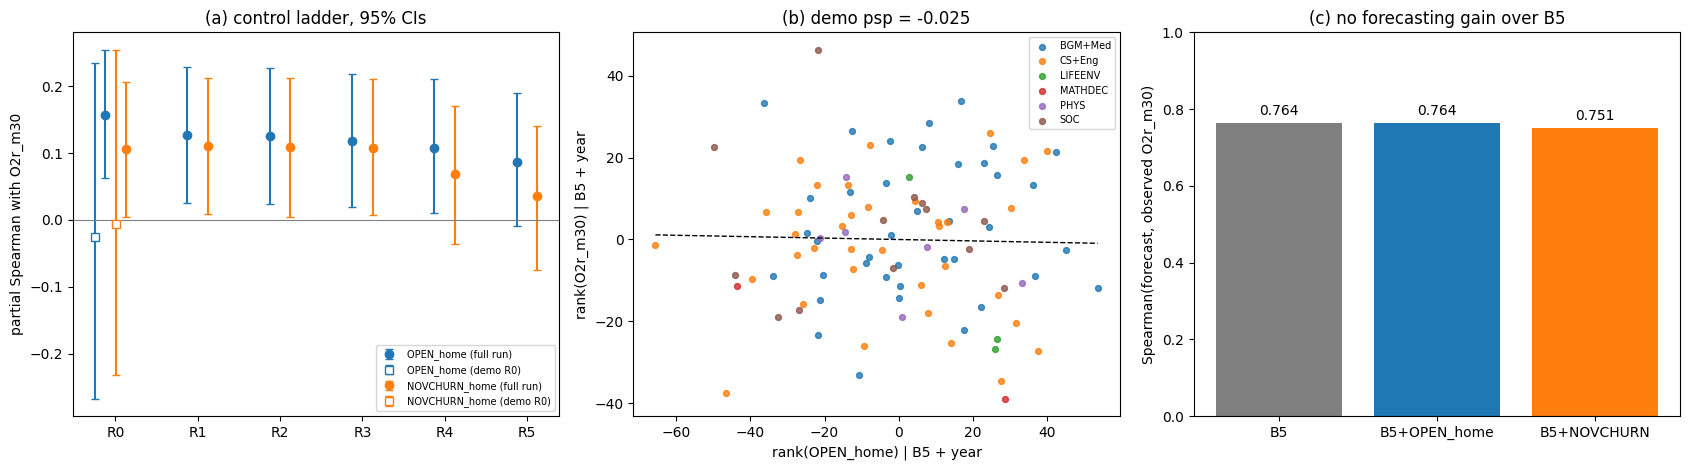

In [12]:
ref = data["metadata"]["full_run_reference_cells"]
tab = []
for xcol in ["OPEN_home", "NOVCHURN_home"]:
    for rung in ["R0", "R1", "R2", "R3", "R4", "R5"]:
        c = ref[f"ladder|{xcol}|O2r_m30|{rung}"]
        tab.append({"index": xcol, "rung": rung, "source": "full run", "n": c["n"], "psp": c["rho"],
                    "ci_lo": c["ci"][0], "ci_hi": c["ci"][1]})
    d = demo[xcol]
    tab.append({"index": xcol, "rung": "R0", "source": f"demo ({N_EXAMPLES} concepts, B={N_BOOT})", "n": d["n"],
                "psp": d["rho"], "ci_lo": d["ci"][0], "ci_hi": d["ci"][1]})
tab = pd.DataFrame(tab)
print(tab.to_string(index=False, float_format=lambda v: f"{v:+.3f}"))

v = data["metadata"]["full_run_verdicts"]
print("\nFrozen verdict:", v["verdict"], "| clauses:", v["clauses"])

fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))
# (a) ladder
for k, (xcol, col) in enumerate([("OPEN_home", "tab:blue"), ("NOVCHURN_home", "tab:orange")]):
    s = tab[(tab["index"] == xcol) & (tab.source == "full run")]
    xs = np.arange(6) + (k - 0.5) * 0.25
    ax[0].errorbar(xs, s.psp, yerr=[s.psp - s.ci_lo, s.ci_hi - s.psp], fmt="o", color=col, capsize=3,
                   label=f"{xcol} (full run)")
    d = demo[xcol]
    ax[0].errorbar([xs[0] - 0.12], [d["rho"]], yerr=[[d["rho"] - d["ci"][0]], [d["ci"][1] - d["rho"]]], fmt="s",
                   mfc="white", color=col, capsize=3, label=f"{xcol} (demo R0)")
ax[0].axhline(0, color="grey", lw=0.8)
ax[0].set_xticks(range(6), ["R0", "R1", "R2", "R3", "R4", "R5"])
ax[0].set_ylabel("partial Spearman with O2r_m30")
ax[0].set_title("(a) control ladder, 95% CIs")
ax[0].legend(fontsize=7)

# (b) residualised ranks for OPEN_home (same computation as psp_point)
Bm, Cm = r0_design(df)
Z = np.hstack([np.ones((len(df), 1)), rankdata(Bm, axis=0), Cm])
R = _resid(Z, np.c_[rankdata(df.OPEN_home), rankdata(df.O2r_m30)])
for g in sorted(df.home_group.unique()):
    m = (df.home_group == g).to_numpy()
    ax[1].scatter(R[m, 0], R[m, 1], s=18, label=g, alpha=0.8)
b = np.polyfit(R[:, 0], R[:, 1], 1)
xx = np.linspace(R[:, 0].min(), R[:, 0].max(), 10)
ax[1].plot(xx, np.polyval(b, xx), "k--", lw=1)
ax[1].set_xlabel("rank(OPEN_home) | B5 + year")
ax[1].set_ylabel("rank(O2r_m30) | B5 + year")
ax[1].set_title(f"(b) demo psp = {demo['OPEN_home']['rho']:+.3f}")
ax[1].legend(fontsize=7)

# (c) forecast ranking on demo concepts
fc = {k: stats.spearmanr(df[k], df.O2r_m30, nan_policy="omit")[0] for k in ["predict_B5", "predict_B5_plus_OPEN_home",
                                                         "predict_B5_plus_NOVCHURN"]}
ax[2].bar(range(3), list(fc.values()), color=["grey", "tab:blue", "tab:orange"])
ax[2].set_xticks(range(3), ["B5", "B5+OPEN_home", "B5+NOVCHURN"])
ax[2].set_ylim(0, 1)
for i, val in enumerate(fc.values()):
    ax[2].text(i, val + 0.02, f"{val:.3f}", ha="center")
ax[2].set_ylabel("Spearman(forecast, observed O2r_m30)")
ax[2].set_title("(c) no forecasting gain over B5")
plt.tight_layout()
plt.show()

## Reading the results
* The full run gives the **PARTIAL** verdict. `OPEN_home` stays positive with a CI above 0 up to rung R4, but
  its R5 CI (home-group fixed effects) includes 0. `NOVCHURN_home` clears 0 at R3.
* The demo subset re-derives the R0 psp with the same code on about a quarter of the concepts. Its estimate is
  near 0 with a CI of about ±0.25, which is consistent with the full-run value. The subset is a lower-tail draw
  (see above), and at n = 100 the test has little power to detect a psp of about 0.15.
* Panel (c) shows the paper's point that the index adds no forecasting gain over the B5 baseline: the ranking
  quality of the forecasts is nearly the same.
* To reproduce the full pipeline, check out the artifact and run `python method.py --from S0 --to S9 --run`.
  This needs the OpenAlex S3 snapshot and the LLM cache.